ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

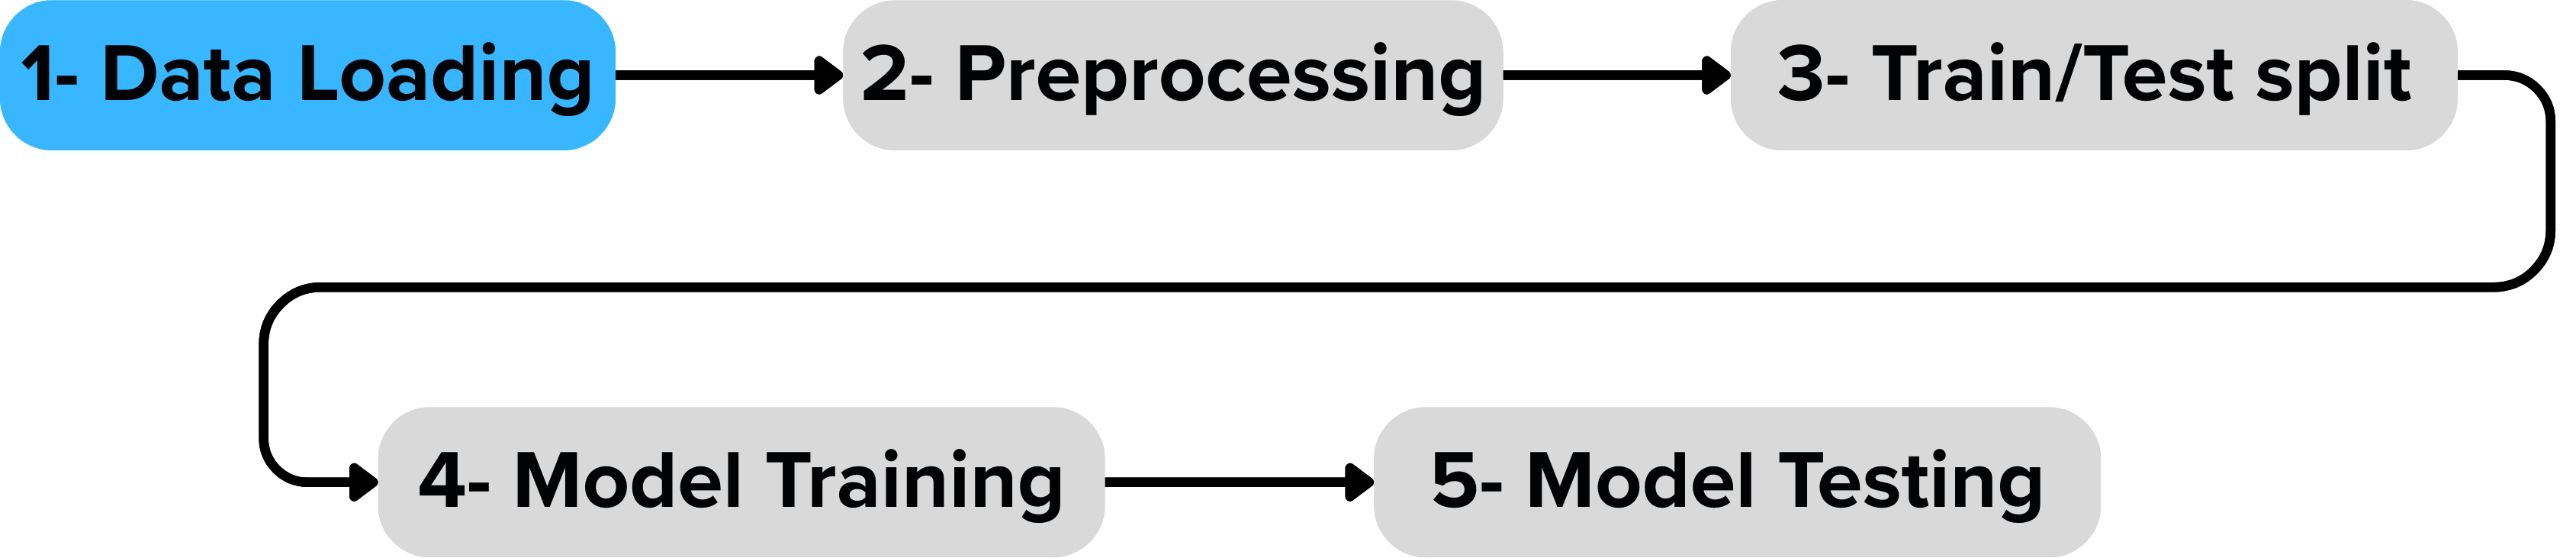

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [2]:
# Load Dataset
df = pd.read_csv("netflix_titles.csv")
# Display first 5 rows. If you want to display all rows, use df.head(-1)
df.head(-1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
993,s994,TV Show,Shadow and Bone,NaN,"Jessie Mei Li, Archie Renaux, Ben Barnes, Fred...",United States,"April 23, 2021",2021,TV-14,1 Season,"TV Action & Adventure, TV Dramas, TV Sci-Fi & ...",Dark forces conspire against orphan mapmaker A...
994,s995,Movie,This Lady Called Life,Kayode Kasum,"Bisola Aiyeola, Efa Iwara, Molawa Onajobi, Tin...",Nigeria,"April 23, 2021",2020,TV-14,120 min,"Dramas, International Movies, Romantic Movies","Abandoned by her family, young single mother A..."
995,s996,Movie,Vizontele,"Yılmaz Erdoğan, Ömer Faruk Sorak","Yılmaz Erdoğan, Demet Akbağ, Altan Erkekli, Ce...",Turkey,"April 23, 2021",2001,TV-MA,106 min,"Comedies, Dramas, International Movies","In 1974, a rural town in Anatolia gets its fir..."
996,s997,Movie,HOMUNCULUS,Takashi Shimizu,"Go Ayano, Ryo Narita, Yukino Kishii, Anna Ishi...",Japan,"April 22, 2021",2021,TV-MA,116 min,"Horror Movies, International Movies, Thrillers",Truth and illusion blurs when a homeless amnes...


### Check Missing Values

In [3]:
# Check all values
print(df.isna())

     show_id   type  title  director   cast  country  date_added  \
0      False  False  False     False   True    False       False   
1      False  False  False      True  False    False       False   
2      False  False  False     False  False     True       False   
3      False  False  False      True   True     True       False   
4      False  False  False      True  False    False       False   
..       ...    ...    ...       ...    ...      ...         ...   
994    False  False  False     False  False    False       False   
995    False  False  False     False  False    False       False   
996    False  False  False     False  False    False       False   
997    False  False  False      True  False    False       False   
998    False  False  False      True  False    False       False   

     release_year  rating  duration  listed_in  description  
0           False   False     False      False        False  
1           False   False     False      False        False

In [4]:
#Before Cleaning
print("\nBefore Cleaning:")
print(df.isna().sum())


Before Cleaning:
show_id           0
type              0
title             0
director        315
cast             97
country         306
date_added        0
release_year      0
rating            0
duration          0
listed_in         0
description       0
dtype: int64


Why cleaning was needed: "Cleaning was necessary because the dataset contained several missing values in key columns like 'director', 'cast', and 'country'. These gaps would lead to inaccurate visualizations and biased insights."

Changes made: "I removed rows with missing values (NaN) to ensure the analysis is based on complete records only."

In [5]:
df.dropna(inplace=True)

#After Cleaning
print("\nAfter Cleaning:")
print(df.isnull().sum())


After Cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


### Check duplicate rows

In [6]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

### No. of rows and columns

In [7]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (462, 12) 

number of rows:  462
number of columns:  12


### Data type of columns

In [8]:
# viewing the data types of columns
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

### 1. Visualizing Content Distribution (Movies vs TV Shows)

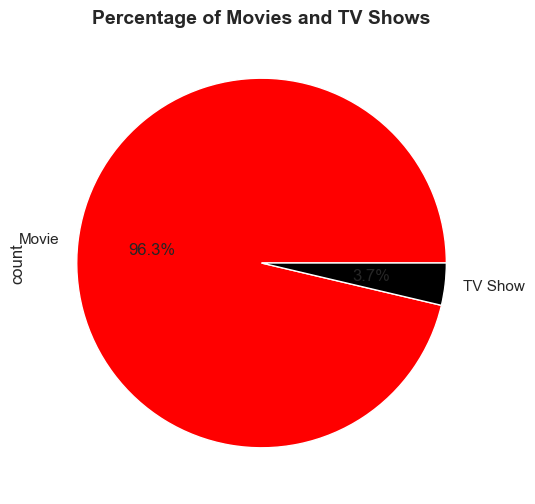

In [9]:
plt.figure(figsize=(8,6))
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['red', 'black'])
plt.title('Percentage of Movies and TV Shows', fontsize=14, fontweight='bold')
plt.show()

Insight: Netflix focuses more on Movies (around 96%) compared to TV Shows, showing its strength as a film streaming platform.

In [10]:
# Statistical summary
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,462,462,462,462,462,462,462,462.000000,462,462,462,462
unique,462,2,462,416,462,111,107,NaN,9,90,130,462
top,s997,Movie,HOMUNCULUS,Clint Eastwood,"Go Ayano, Ryo Narita, Yukino Kishii, Anna Ishi...",United States,"July 1, 2021",NaN,TV-MA,97 min,Action & Adventure,Truth and illusion blurs when a homeless amnes...
freq,1,445,1,4,1,183,48,NaN,118,20,25,1
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010.361472,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.874021,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1959.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


### Descriptive summary Statistics

### 2. Top 10 Countries

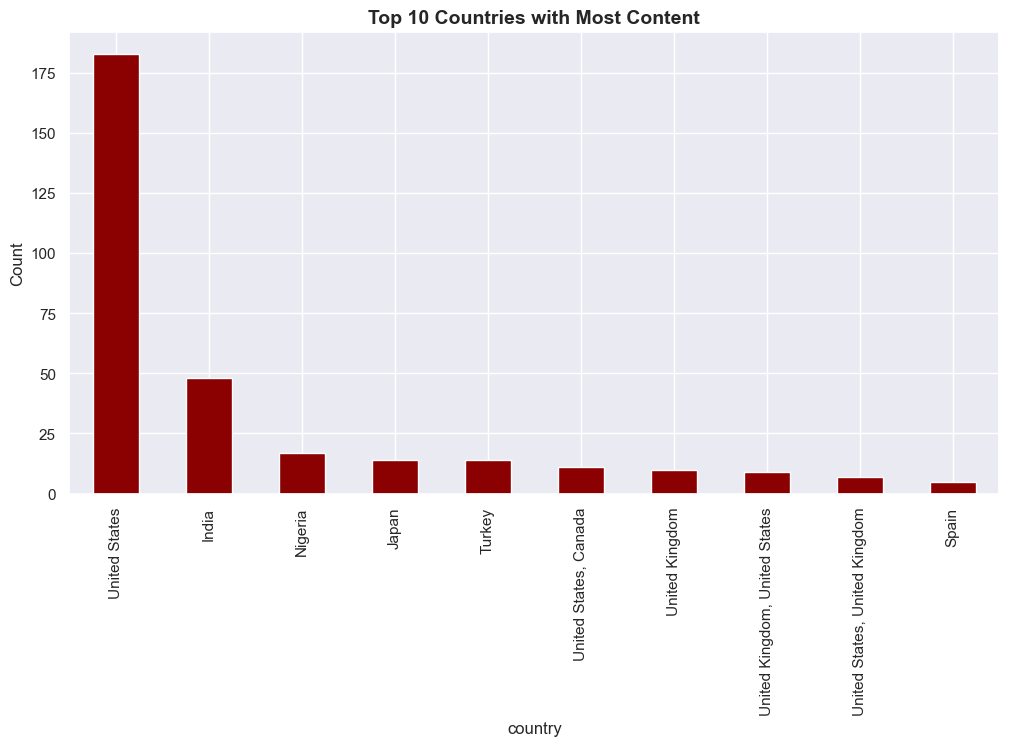

In [11]:
plt.figure(figsize=(12,6))
df['country'].value_counts().head(10).plot(kind='bar', color='darkred')
plt.title('Top 10 Countries with Most Content', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.show()

Insight: The United States is the leading producer of Netflix content, followed by India and the UK.

### 3. Growth of Content Added Over the Years

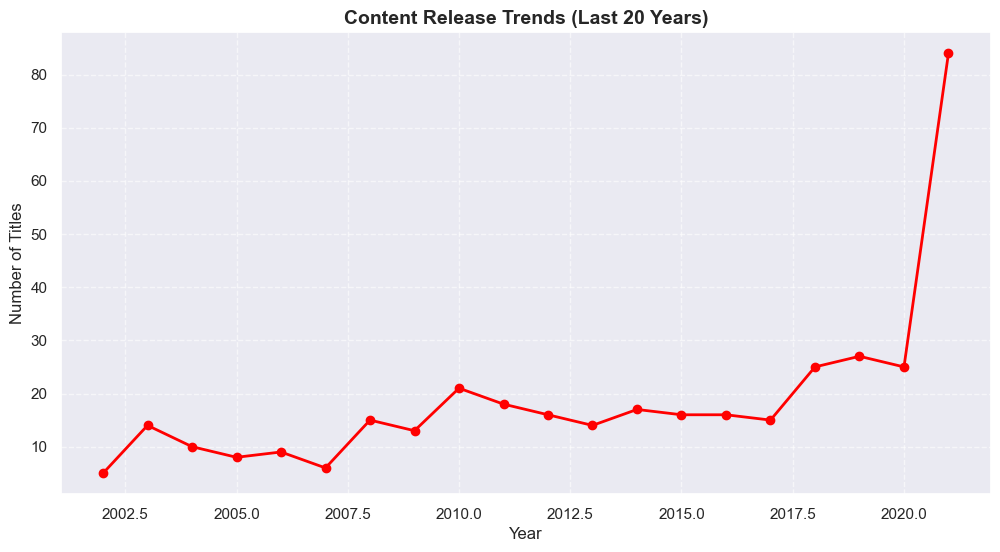

In [12]:
plt.figure(figsize=(12,6))
df['release_year'].value_counts().sort_index().tail(20).plot(kind='line', marker='o', color='red', linewidth=2)
plt.title('Content Release Trends (Last 20 Years)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Insight: There is a massive growth in content added after 2015, peaking around 2019, which shows Netflix's rapid expansion.



### 4. Content Ratings Analysis

C:\Users\aalya\AppData\Local\Temp\ipykernel_26300\1303043109.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='Reds_r')


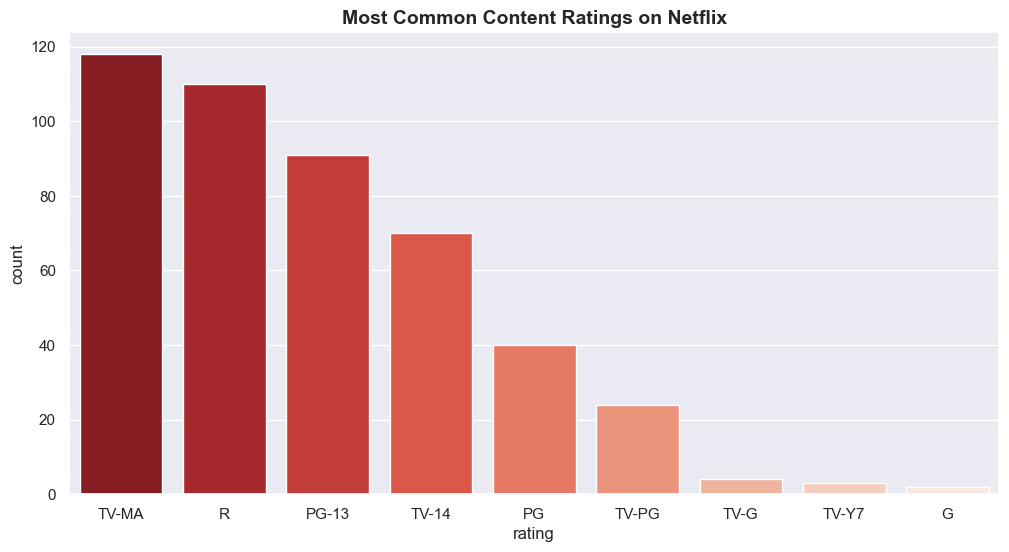

In [13]:
plt.figure(figsize=(12,6))
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='Reds_r')
plt.title('Most Common Content Ratings on Netflix', fontsize=14, fontweight='bold')
plt.show()

Insight: The "TV-MA" rating is the most common, indicating that a large portion of Netflix content is targeted at adult audiences.

### 5. Top 10 Genres

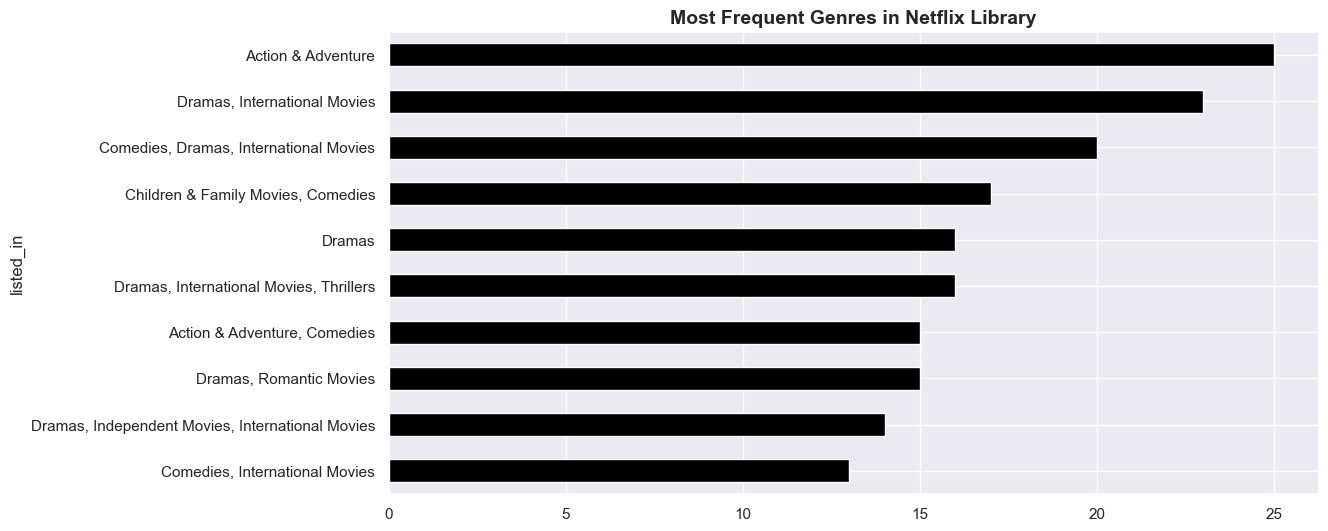

In [14]:
plt.figure(figsize=(12,6))
df['listed_in'].value_counts().head(10).plot(kind='barh', color='black')
plt.gca().invert_yaxis()
plt.title('Most Frequent Genres in Netflix Library', fontsize=14, fontweight='bold')
plt.show()

Insight: Action and Adventure movies are the most popular genres available on the platform.

### 6. Release Year Distribution

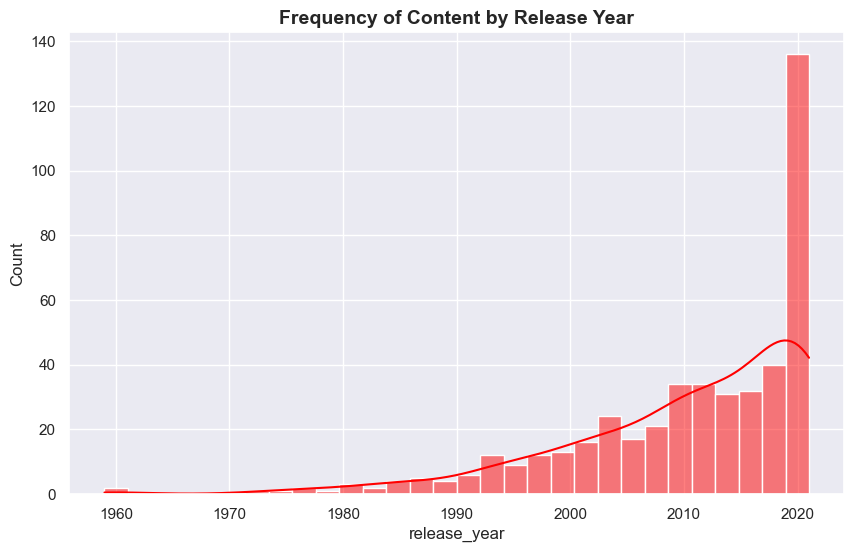

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(df['release_year'], bins=30, kde=True, color='red')
plt.title('Frequency of Content by Release Year', fontsize=14, fontweight='bold')
plt.show()

Insight: Most content on Netflix is relatively new, with a high density of titles released between 2010 and 2021.

### 7. Release Year vs Content Type

C:\Users\aalya\AppData\Local\Temp\ipykernel_26300\812450687.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='release_year', data=df, palette='Set1')


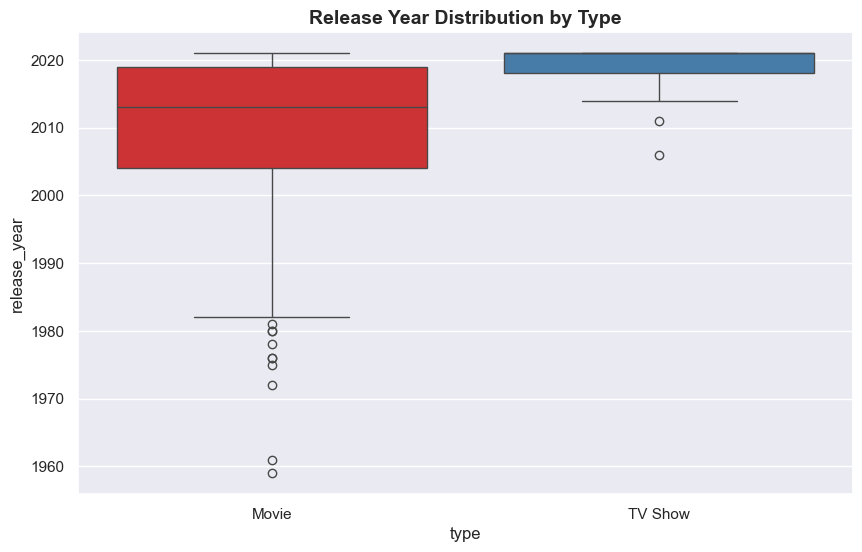

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(x='type', y='release_year', data=df, palette='Set1')
plt.title('Release Year Distribution by Type', fontsize=14, fontweight='bold')
plt.show()

Insight: TV Shows tend to have more recent release dates on average compared to Movies.

### 8. Data Cleanliness Verification

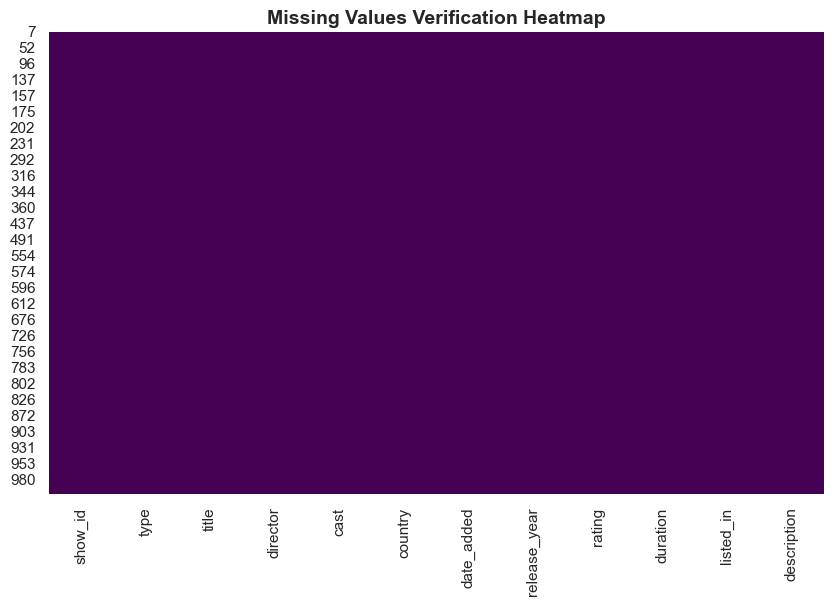

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Verification Heatmap', fontsize=14, fontweight='bold')
plt.show()

Insight: This visualization confirms that the dataset is now clean after our preprocessing steps.

### 9. TV Shows Duration (Seasons)

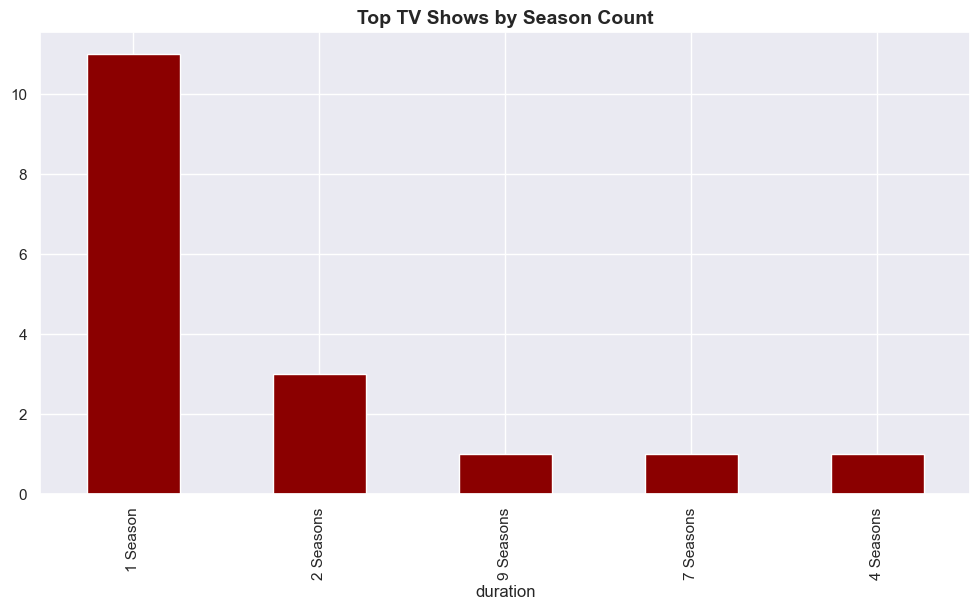

In [18]:
tv_shows = df[df['type'] == 'TV Show']
plt.figure(figsize=(12,6))
tv_shows['duration'].value_counts().head(10).plot(kind='bar', color='darkred')
plt.title('Top TV Shows by Season Count', fontsize=14, fontweight='bold')
plt.show()

Insight: Most TV Shows on Netflix only have one season, suggesting many are limited series or newly started.

### 10. Leading Directors

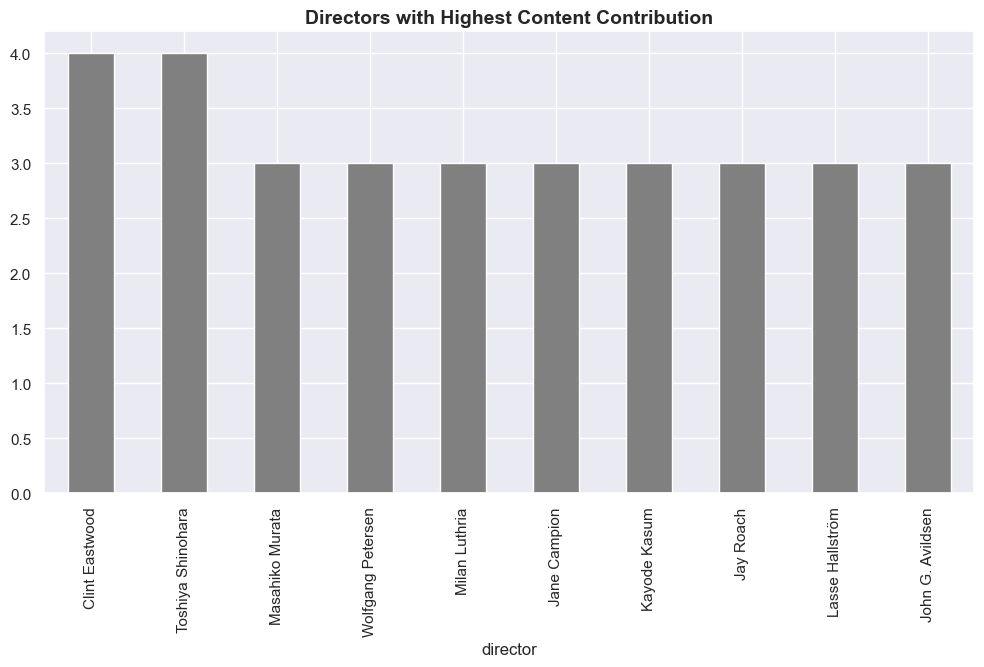

In [19]:
plt.figure(figsize=(12,6))
df['director'].value_counts().head(10).plot(kind='bar', color='grey')
plt.title('Directors with Highest Content Contribution', fontsize=14, fontweight='bold')
plt.show()

Insight: This chart identifies the most frequent directors contributing to Netflix's library.

Why these plots? "I chose these 10 plots (Pie chart, Bar charts, Heatmaps, etc.) because they effectively show the proportion of content types, the growth over time, and the categorical distribution of ratings and genres."

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file 
2. Dataset Description readme file
2. Jupyter Notebook


Conclusion: This EDA reveals that Netflix's library is dominated by international movies, with a significant growth in content production over the last decade.